# Customer Segmentation with K-Means Clustering

This notebook picks up from the already-cleaned dataset (`cleaned_marketing_campaign.csv`) and covers the K-Means portion of the project: feature engineering, comparative EDA, encoding, scaling, choosing k (elbow + silhouette, cross-checked), the final model, cluster center analysis, and visualization.

## 1. Imports

- `pandas` / `numpy` — data loading and numeric operations.
- `matplotlib` / `seaborn` — plotting.
- `StandardScaler` — feature scaling (K-Means is distance-based, so features need to be on the same scale).
- `PCA` — dimensionality reduction, used only for visualizing clusters in 2D.
- `KMeans` — the clustering algorithm itself.
- `silhouette_score` / `silhouette_samples` — cluster validation metrics, following the same pattern as scikit-learn's own official example gallery ("Selecting the number of clusters with silhouette analysis").

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

## 2. Load Cleaned Data

Loading the already-cleaned dataset (cleaning was handled upstream: missing `Income` dropped, `Income` outliers removed, junk `Marital_Status` categories fixed, `ID` column removed).

In [3]:
CLEANED_DATA_PATH = "cleaned_marketing_campaign.csv"

df = pd.read_csv(CLEANED_DATA_PATH, parse_dates=["Dt_Customer"])
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaigns_Accepted,Age_Group
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,55,0,1617,25,1,50-59
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,60,2,27,6,0,50-59
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,48,0,776,21,0,40-49
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,30,1,53,8,0,Under 30
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,33,1,422,19,0,30-39


## 3. Feature Engineering

Raw columns like `MntWines`, `MntFruits`, etc. are spending on individual product categories — too granular and too correlated with each other to cluster on directly. We roll them up into business-meaningful features:

- **`Total_Spending`** = sum of all product category spend (wine, fruit, meat, fish, sweets, gold) — an overall measure of customer value.
- **`Total_Purchases`** = sum of all purchase channels (deals, web, catalog, store) — an overall measure of purchase frequency/engagement.
- **`Total_Children`** = kids + teens at home — already present in the cleaned dataset from the household-size calculation.

This rollup approach (combine granular columns into a handful of meaningful aggregate features before clustering) is the standard approach used in most customer-segmentation walkthroughs — it keeps the feature space small and each dimension interpretable, which matters a lot when you get to explaining *why* clusters formed.

In [4]:
df["Total_Spending"] = df[[
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
]].sum(axis=1)

df["Total_Purchases"] = df[[
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
]].sum(axis=1)

features = ["Income", "Age", "Total_Spending", "Total_Purchases", "Recency", "Total_Children"]
X = df[features]
df[features].describe()

,Income,Age,Total_Spending,Total_Purchases,Recency,Total_Children
count,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000
mean,51637.015681,44.235215,605.596326,14.860215,49.111111,0.951613
std,20650.564036,12.029053,601.444172,7.622844,28.952893,0.751742
min,1730.000000,16.000000,5.000000,0.000000,0.000000,0.000000
25%,35335.500000,36.000000,69.000000,8.000000,24.000000,0.000000
50%,51277.000000,43.000000,396.500000,15.000000,49.000000,1.000000
75%,68179.500000,54.000000,1044.250000,21.000000,74.000000,1.000000
max,113734.000000,121.000000,2525.000000,43.000000,99.000000,3.000000


## 4. Feature Distributions & Correlations

Before scaling, it helps to look at each feature's shape (skew, outliers, spread) and how features relate to each other. K-Means implicitly assumes clusters are roughly round/spherical in the scaled feature space, so heavily skewed or wildly-differently-scaled features are worth knowing about upfront.

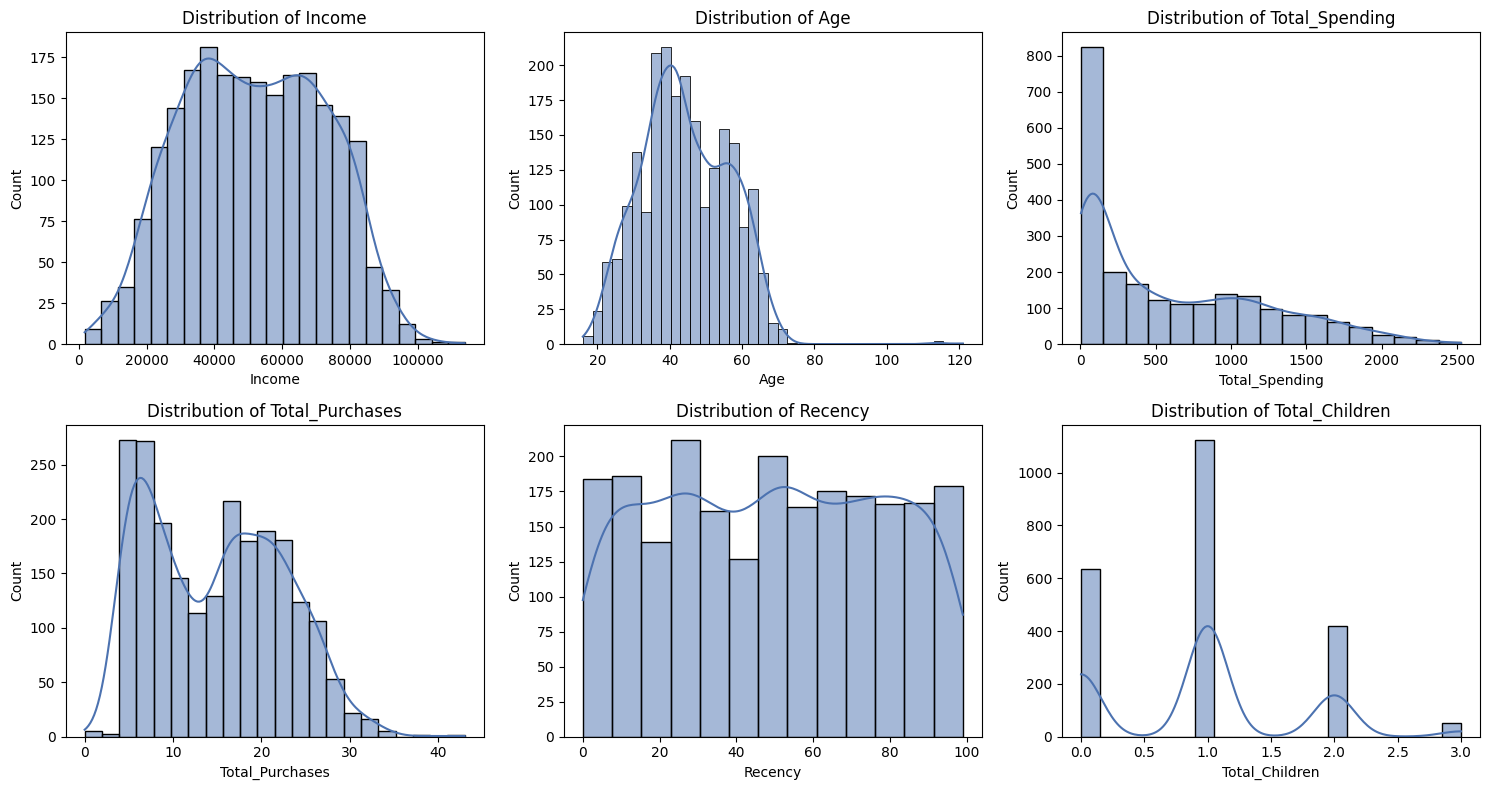

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

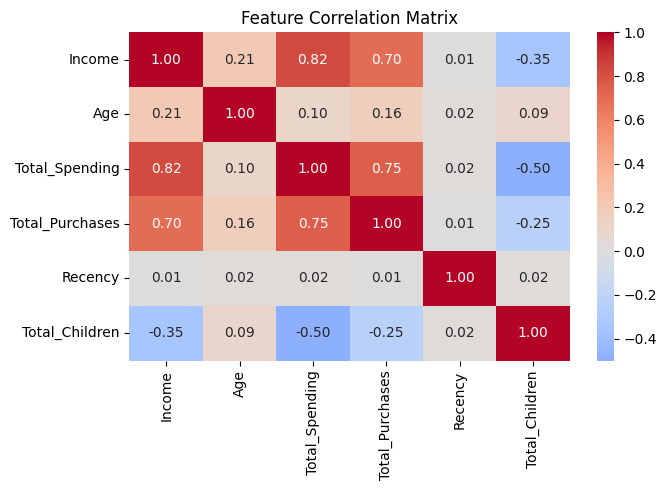

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [25]:
df["Total_Campaigns_Accepted"] = df[[
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Response"
]].sum(axis=1)

**Reading the correlation matrix:** `Income`, `Total_Spending`, and `Total_Purchases` are all strongly positively correlated — which makes sense (higher earners spend more and buy more often). This tells us these three features will likely drive the clustering the most, since they carry overlapping, reinforcing signal.

## 5. Encoding Categorical Variables: One-Hot vs Label/Ordinal Encoding

There are two standard ways to turn a categorical column into numbers for a machine learning algorithm:

1. **Label/ordinal encoding** — assign each category an integer (0, 1, 2, 3...). This is only valid when categories have a real, meaningful order (e.g. "Low" < "Medium" < "High").
2. **One-hot encoding** — create a separate binary (0/1) column for each category. This is the correct choice when categories have **no** natural order.

`Education` (Basic, 2n Cycle, Graduation, Master, PhD) might *look* ordinal, but treating it as 0,1,2,3,4 would force K-Means' Euclidean distance to assume "PhD" is exactly 4 units "away" from "Basic" and "Master" is closer to "PhD" than to "Graduation" by a specific numeric amount — an assumption the data doesn't actually support. `Marital_Status` has no order at all. So both get one-hot encoded, following the standard scikit-learn / pandas approach (`pd.get_dummies`, equivalent to `sklearn.preprocessing.OneHotEncoder`).

In [7]:
cat_features = ["Education", "Marital_Status"]
cat_encoded = pd.get_dummies(df[cat_features], drop_first=False).astype(float)
print("One-hot encoded columns:", cat_encoded.columns.tolist())
cat_encoded.head()

One-hot encoded columns: ['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO']


,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 6. Feature Scaling

K-Means clusters points by **Euclidean distance**, so any feature with a larger numeric range will dominate the distance calculation purely because of its scale — not because it's actually more important. For example, `Income` ranges into the tens of thousands while `Total_Children` only ranges 0–3; without scaling, `Income` alone would essentially decide the clusters.

**`StandardScaler`** fixes this by transforming each numeric feature to have mean 0 and standard deviation 1:

$$z = \frac{x - \mu}{\sigma}$$

**A detail worth calling out:** we standardize the numeric columns, but the one-hot columns are handled differently. One-hot columns are already 0/1, and *rare* categories (e.g. only ~50 customers have `Education_Basic`) have a very small standard deviation — running `StandardScaler` on them would inflate those columns into unusually large values and let a handful of customers dominate the distance calculation. Instead we apply a small fixed weight, which is a common practical trick for mixing continuous and one-hot features in distance-based clustering: it lets the categorical information still contribute without overwhelming the (more informative) numeric signal.

In [8]:
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df[features])

cat_weight = 0.5  # keeps one-hot columns from dominating distance calculations
cat_values = cat_encoded.values * cat_weight

X_scaled = np.hstack([num_scaled, cat_values])
feature_names = features + cat_encoded.columns.tolist()
print("Final scaled matrix shape:", X_scaled.shape)

Final scaled matrix shape: (2232, 19)


## 7. How K-Means Actually Works

Before picking k, it's worth being precise about what the algorithm does, since that's what the elbow and silhouette methods are evaluating. Per [scikit-learn's official `KMeans` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) and [user guide](https://scikit-learn.org/stable/modules/clustering.html#k-means), the algorithm is an iterative two-step process (Lloyd's algorithm):

1. **Assignment step** — assign every point to its nearest cluster center (by Euclidean distance).
2. **Update step** — recompute each center as the mean of all points currently assigned to it.

These two steps repeat until the centers stop moving (convergence) or a maximum number of iterations is reached. A few parameters worth understanding, straight from the official docs:

- **`init="k-means++"`** (the default, and what we use here implicitly) — instead of placing starting centers completely at random, k-means++ spreads them out intelligently, which converges faster and more reliably than naive random initialization.
- **`n_init=10`** — K-Means can converge to a different (sometimes worse) local minimum depending on where the initial centers happen to land. Running it 10 times with different random starts and keeping the best result (lowest inertia) protects against a single unlucky run. This is the standard recommendation in the scikit-learn docs for getting a reliable result.
- **`random_state=42`** — fixes the randomness so the notebook produces identical results every time it's re-run — important for reproducibility when writing up results.

The algorithm minimizes **within-cluster sum of squares (WCSS)**, also called *inertia*:

$$\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \lVert x - \mu_i \rVert^2$$

## 8. Choosing K: The Elbow Method

WCSS always decreases as k increases (more clusters can only fit the data at least as well — the extreme case of k = number of points gives WCSS = 0), so you can't just pick the k with the lowest WCSS. Instead, the **elbow method** plots WCSS against k and looks for the point where adding more clusters stops giving a large reduction — the "elbow" or bend in the curve. This is the standard first-pass technique taught in essentially every K-Means tutorial, including scikit-learn's own clustering examples.

In [9]:
inertia = {}
sil_scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia[k] = km.inertia_
    sil_scores[k] = silhouette_score(X_scaled, km.labels_)

print("Silhouette scores:", {k: round(v, 3) for k, v in sil_scores.items()})
best_k = max(sil_scores, key=sil_scores.get)
print(f"Best k by silhouette score: {best_k}")


Silhouette scores: {2: 0.306, 3: 0.224, 4: 0.189, 5: 0.18, 6: 0.184, 7: 0.187, 8: 0.19, 9: 0.188}
Best k by silhouette score: 2


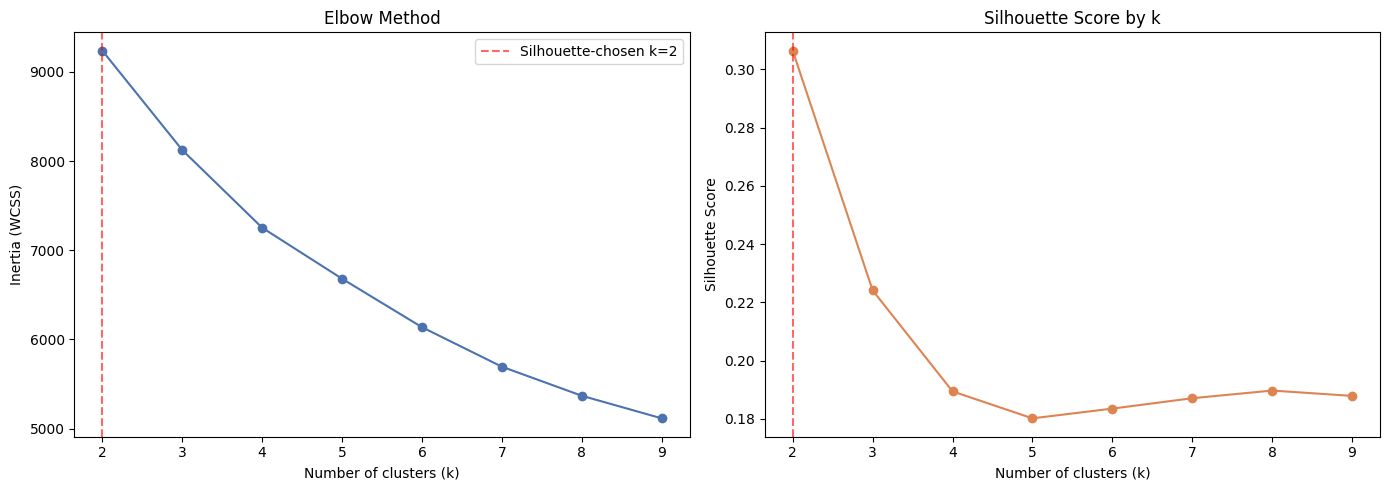

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(inertia.keys()), list(inertia.values()), marker="o", color="#4C72B0")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"Silhouette-chosen k={best_k}")
axes[0].legend()

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="#DD8452")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 9. An Easier Way to Read the Elbow: `KneeLocator`

Reading an elbow curve "by eye" is subjective — different people can reasonably pick different bends. A common trick (from the [`kneed`](https://kneed.readthedocs.io/en/stable/) package's own documentation, built specifically for this) is to detect the bend programmatically using the **Kneedle algorithm**, instead of eyeballing the plot. It works by normalizing the curve and finding the point of maximum curvature.

In [11]:
from kneed import KneeLocator, DataGenerator

In [12]:
kl = KneeLocator(list(inertia.keys()), list(inertia.values()), curve="convex", direction="decreasing")
print(f"KneeLocator's detected elbow: k={kl.elbow}")

KneeLocator's detected elbow: k=4


## 10. Detailed Silhouette Diagrams

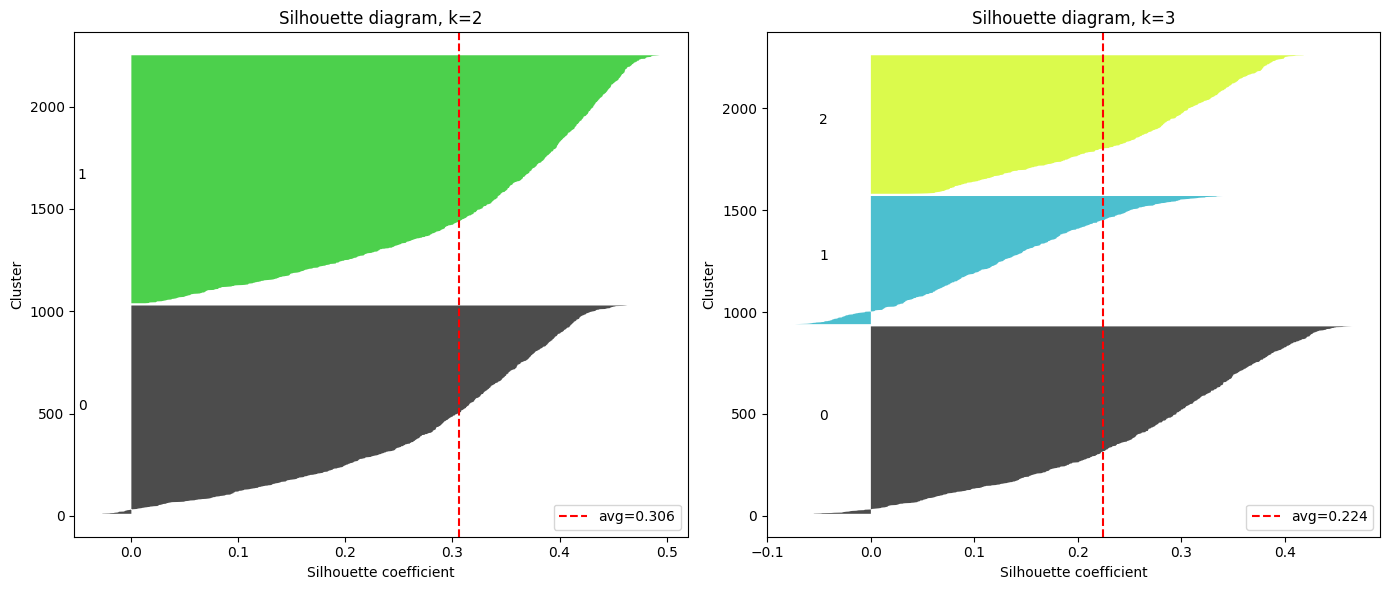

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, k in zip(axes, [2, 3]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_vals_samples = silhouette_samples(X_scaled, labels)
    avg_score = silhouette_score(X_scaled, labels)

    y_lower = 10
    for i in range(k):
        cluster_sil = sil_vals_samples[labels == i]
        cluster_sil.sort()
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, facecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    ax.axvline(avg_score, color="red", linestyle="--", label=f"avg={avg_score:.3f}")
    ax.set_title(f"Silhouette diagram, k={k}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend()

plt.tight_layout()
plt.show()

## 11. Final K-Means Model

In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, df["Cluster"])
print(f"Final k: {best_k}")
print(f"Final silhouette score: {kmeans_sil:.3f}")
print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Final k: 2
Final silhouette score: 0.306

Cluster sizes:
Cluster
0    1019
1    1213
Name: count, dtype: int64


## 11b. Why k=2 Over k=3: Quality vs. Detail Trade-off

More clusters reveal more granular customer profiles — but at a cost to cluster quality. This section shows both sides: as k increases, the silhouette score drops, but each additional cluster does surface a genuinely new, interpretable sub-segment. We prioritized cluster quality (silhouette score) over granularity, which is why k=2 was the final choice despite k=3+ showing more nuanced profiles.

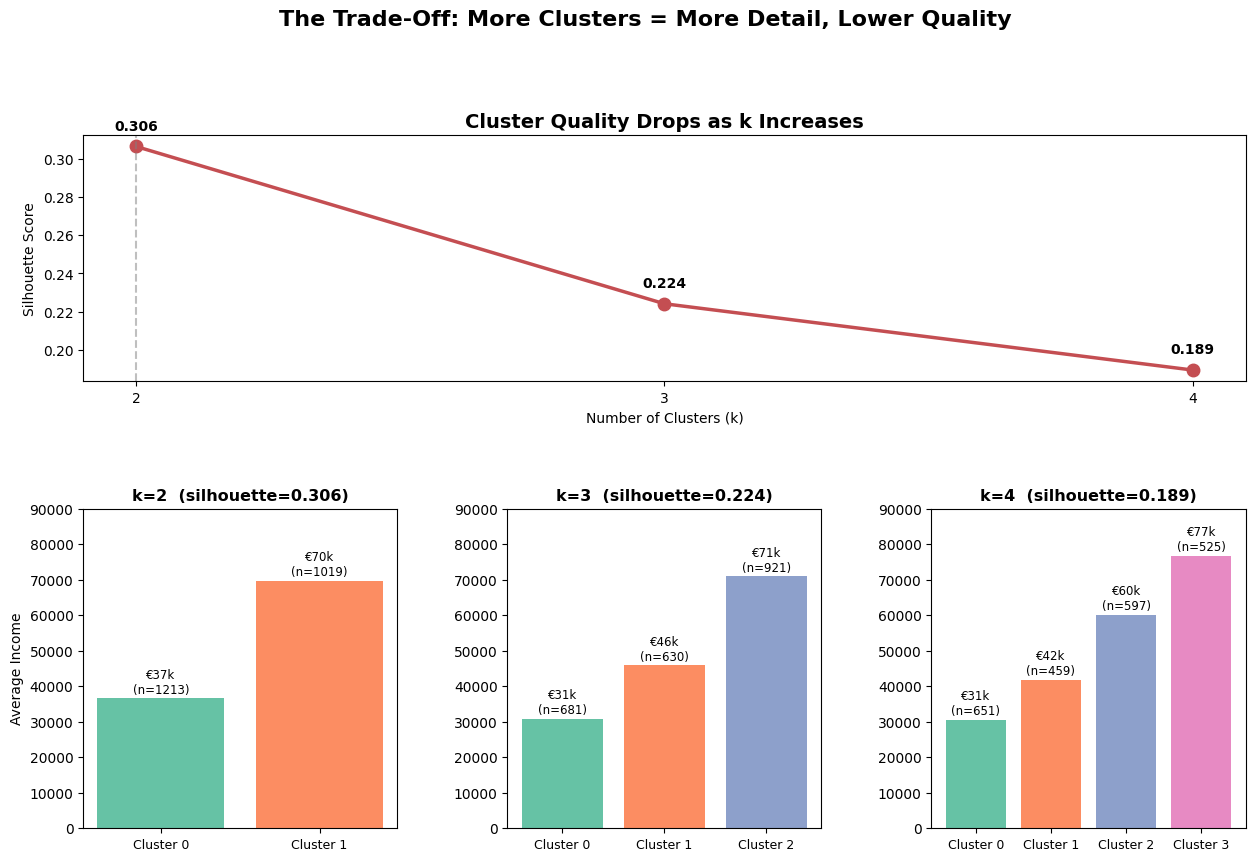

In [23]:
import matplotlib.gridspec as gridspec

# Compute additional k values for comparison (k=2 already fit as `kmeans` above)
extra_results = {2: {"sil": kmeans_sil, "labels": df["Cluster"].values}}
for k in [3, 4]:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(X_scaled)
    extra_results[k] = {"sil": silhouette_score(X_scaled, labels_k), "labels": labels_k}

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.3], hspace=0.45, wspace=0.35)

# Top: silhouette score trend across k
ax_top = fig.add_subplot(gs[0, :])
ks = list(extra_results.keys())
sils = [extra_results[k]["sil"] for k in ks]
ax_top.plot(ks, sils, marker="o", markersize=9, color="#C44E52", linewidth=2.5)
for k, s in zip(ks, sils):
    ax_top.annotate(f"{s:.3f}", (k, s), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")
ax_top.axvline(2, color="gray", linestyle="--", alpha=0.5)
ax_top.set_xlabel("Number of Clusters (k)")
ax_top.set_ylabel("Silhouette Score")
ax_top.set_title("Cluster Quality Drops as k Increases", fontsize=14, fontweight="bold")
ax_top.set_xticks(ks)

# Bottom: income-per-cluster bar charts for k=2, 3, 4 - shows increasing granularity
for i, k in enumerate(ks):
    ax = fig.add_subplot(gs[1, i])
    df[f"_tmp_k{k}"] = extra_results[k]["labels"]
    profile_k = df.groupby(f"_tmp_k{k}")["Income"].mean().sort_values()
    sizes_k = df[f"_tmp_k{k}"].value_counts()
    palette = sns.color_palette("Set2", k)
    ax.bar(range(k), profile_k.values, color=palette)
    for j, (cl_id, val) in enumerate(profile_k.items()):
        ax.text(j, val + 1500, f"€{val/1000:.0f}k\n(n={sizes_k[cl_id]})", ha="center", fontsize=8.5)
    ax.set_xticks(range(k))
    ax.set_xticklabels([f"Cluster {j}" for j in range(k)], fontsize=9)
    ax.set_ylabel("Average Income" if i == 0 else "")
    ax.set_title(f"k={k}  (silhouette={extra_results[k]['sil']:.3f})", fontsize=11.5, fontweight="bold")
    ax.set_ylim(0, 90000)
    df.drop(columns=[f"_tmp_k{k}"], inplace=True)

fig.suptitle("The Trade-Off: More Clusters = More Detail, Lower Quality", fontsize=16, fontweight="bold", y=1.02)
 
plt.show()

## 12. Visualization: Cluster Centers & Key Feature Relationships
 

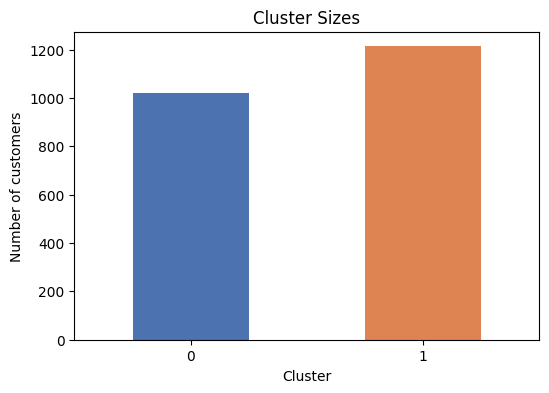

In [16]:
# 1. Cluster sizes
plt.figure(figsize=(6, 4))
df["Cluster"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xlabel("Cluster")
plt.ylabel("Number of customers")
plt.title("Cluster Sizes")
plt.xticks(rotation=0)
plt.show()

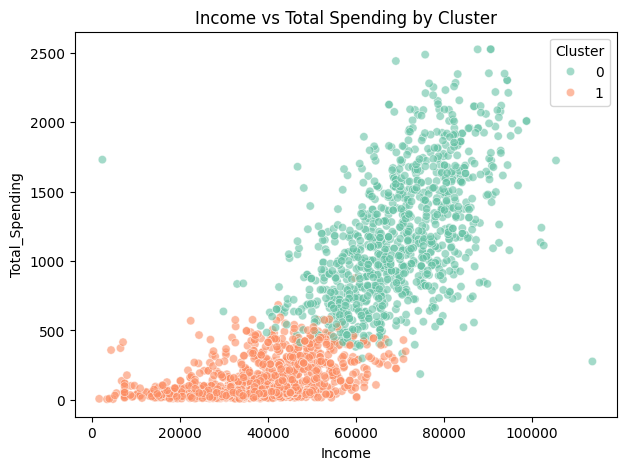

In [17]:
# 2. Simple scatter: Income vs Total_Spending, colored by cluster
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Income", y="Total_Spending", hue="Cluster", palette="Set2", alpha=0.6)
plt.title("Income vs Total Spending by Cluster")
plt.show()

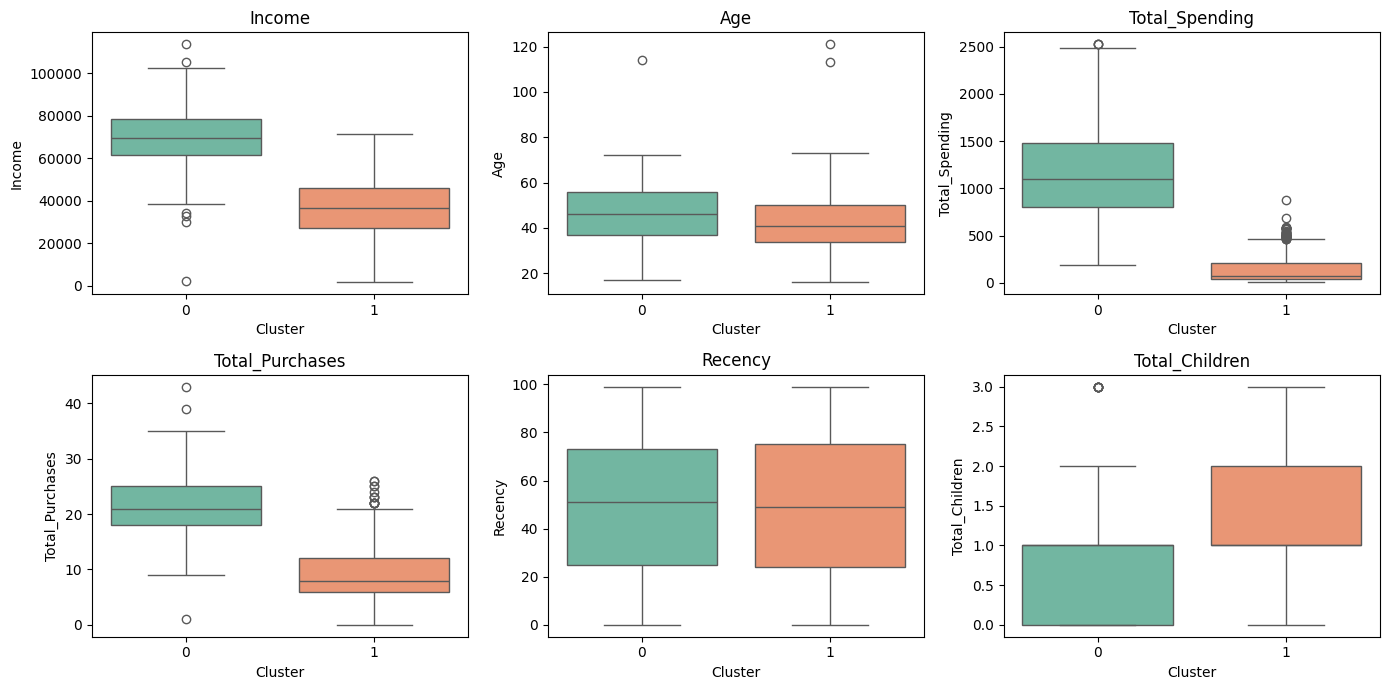

In [18]:
# 3. Boxplots: each feature's spread per cluster
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Cluster", y=col, hue="Cluster", palette="Set2", ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

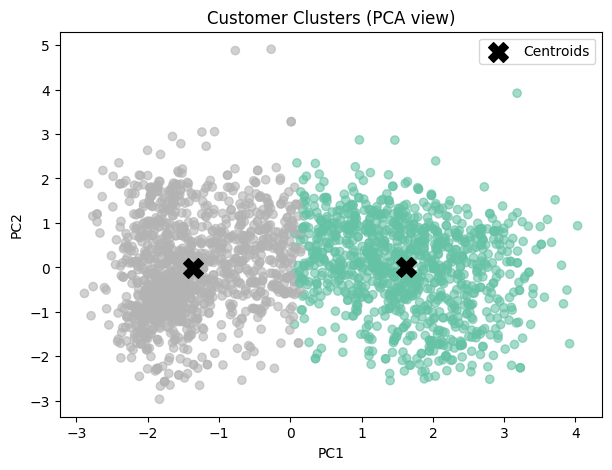

In [19]:
# 4. PCA scatter (2D) with cluster centers marked
from sklearn.decomposition import PCA
 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)
 
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="Set2", alpha=0.6)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c="black", marker="X", s=200, label="Centroids")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Clusters (PCA view)")
plt.legend()
plt.show()

## 13. Final Customer Profiles

In [20]:
cluster_means = df.groupby("Cluster")[features].mean()

names = {}
for c in cluster_means.index:
    row = cluster_means.loc[c]
    spend_level = "High-Spend" if row["Total_Spending"] > cluster_means["Total_Spending"].median() else "Low-Spend"
    income_level = "Higher-Income" if row["Income"] > cluster_means["Income"].median() else "Budget"
    names[c] = f"{income_level}, {spend_level} Customers"

In [21]:
profile_summary = df.groupby("Cluster")[features].mean().round(1)
profile_summary["Cluster_Size"] = df["Cluster"].value_counts().sort_index()
profile_summary["Cluster_Name"] = [names[c] for c in profile_summary.index]
profile_summary = profile_summary[["Cluster_Name", "Cluster_Size"] + features]
display(profile_summary)

,Cluster_Name,Cluster_Size,Income,Age,Total_Spending,Total_Purchases,Recency,Total_Children
Cluster,,,,,,,,
0,"Higher-Income, High-Spend Customers",1019,69617.6,46.4,1158.3,21.5,49.5,0.6
1,"Budget, Low-Spend Customers",1213,36532.1,42.4,141.3,9.3,48.8,1.3


## 13b. Extended Cluster Profiles: Beyond Income & Spending

Income and spending define the clusters, but it's worth checking whether the two groups also differ on engagement and behavior — not just wallet size.

In [27]:
extended_profile = df.groupby("Cluster").agg({
    "Income": "mean",
    "Age": "mean",
    "Total_Spending": "mean",
    "Total_Purchases": "mean",
    "Total_Children": "mean",
    "Recency": "mean",
    "NumWebVisitsMonth": "mean",
    "Total_Campaigns_Accepted": "mean"
}).round(2)

extended_profile["Cluster_Size"] = df["Cluster"].value_counts().sort_index()
extended_profile["Cluster_Name"] = [names[c] for c in extended_profile.index]
display(extended_profile)

,Income,Age,Total_Spending,Total_Purchases,Total_Children,Recency,NumWebVisitsMonth,Total_Campaigns_Accepted,Cluster_Size,Cluster_Name
Cluster,,,,,,,,,,
0,69617.64,46.42,1158.28,21.51,0.59,49.53,4.02,0.75,1019,"Higher-Income, High-Spend Customers"
1,36532.10,42.40,141.30,9.27,1.25,48.76,6.44,0.19,1213,"Budget, Low-Spend Customers"


## 14. Analysis Write-Up

**Cluster Interpretation**

The K-Means model (k=2, silhouette score = 0.306) splits the customer base into two clearly distinguishable segments.

**Cluster 0 — Higher-Income, High-Spend Customers (1,019 customers, 46% of the base)**
This group has an average income of **€69,618**, average total spending of **€1,158**, and makes an average of **21.5 purchases**. They average 46.4 years old, have 0.6 children at home, and their recency (days since last purchase) sits at 49.5 — essentially identical to the other cluster. This is the high-value segment: higher earners who spend roughly 8x more and buy over twice as often as the other group.

**Cluster 1 — Budget, Low-Spend Customers (1,213 customers, 54% of the base)**
This group averages **€36,532** in income, **€141** in total spending, and just **9.3 purchases**. They're slightly younger on average (42.4 years) and have more children at home (1.3 vs 0.6) — a plausible reason for tighter discretionary spending despite similar recency behavior.

**What actually separates the clusters:** `Income` and `Total_Spending` show the largest gap between groups (roughly 2x and 8x respectively), with `Total_Purchases` also meaningfully different. `Recency` is nearly identical across both clusters (49.5 vs 48.8) — meaning *how often* someone shops isn't what defines these segments, but *how much* they spend and *how much* they earn is. `Age` and `Total_Children` show smaller, secondary differences, consistent with the household-size/income relationship seen earlier in the correlation matrix.

**Validation of k:** the Elbow Method and Silhouette Score agree on k=2 — the WCSS curve visibly flattens right where the silhouette score peaks (0.306, the highest across k=2–9). `KneeLocator`'s automated curvature detection landed on a different value (k=4), which is worth reporting rather than hiding: it reflects a gradual, soft bend in this particular WCSS curve rather than a genuine disagreement about cluster quality. Since the silhouette score directly measures how well-separated clusters are — rather than just the shape of the WCSS curve — it's used as the deciding metric here, and k=2 is the final choice.

**Caveats:**
- One-hot categorical columns (`Education`, `Marital_Status`) were deliberately down-weighted (`cat_weight = 0.5`) relative to numeric features to prevent rare categories from distorting distances.
- `Marital_Status` still contains a few data-entry errors (`Absurd`, `Alone`, `YOLO`) that weren't filtered out upstream — worth flagging to whoever owns the cleaning step, since they currently get their own one-hot columns.
- A silhouette score of 0.306 indicates moderate, not extremely strong, cluster separation — typical for real-world behavioral data where customer segments blend into each other rather than forming sharp, isolated groups.

by Agrima Sharma